# Projet Eulogia — Clustering K-Means (Groupe 2)

**Objectif :** Segmenter les pays africains selon leur profil électrique à partir du jeu de données préparé par le Groupe 1.

**Données :** `Donnees_Electricite_preparees_KMeans_CORRIGE.xlsx` — feuille `Profil_normalise_KMeans` (54 pays, 25 indicateurs normalisés).

**Étapes :**
1. Entraîner K-Means pour *k* = 2 à 10
2. Déterminer le *k* optimal (coude + silhouette)
3. Analyser les clusters (profils moyens, pays représentatifs, interprétation énergétique)

In [1]:
# Imports et configuration
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")

# Chemins (adapter si nécessaire)
BASE_DIR = Path(r"D:/BECKER/Eulogia")
DATA_PATH = BASE_DIR / "Donnees_Electricite_preparees_KMeans_CORRIGE.xlsx"
OUT_DIR = BASE_DIR / "outputs"
OUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
K_RANGE = range(2, 11)

## 1. Chargement des données

Le Groupe 1 a déjà nettoyé, agrégé (moyenne 2005–2021) et normalisé (StandardScaler) les indicateurs. Nous utilisons directement la feuille **`Profil_normalise_KMeans`** pour l'apprentissage, et **`Profil_pays`** pour l'interprétation en unités originales.

In [2]:
df_norm = pd.read_excel(DATA_PATH, sheet_name="Profil_normalise_KMeans")
df_raw = pd.read_excel(DATA_PATH, sheet_name="Profil_pays")

countries = df_norm["Country"].reset_index(drop=True)
feature_cols = [c for c in df_norm.columns if c != "Country"]
X = df_norm[feature_cols].values

print(f"Nombre de pays : {len(countries)}")
print(f"Nombre de variables : {len(feature_cols)}")
print("\nVariables utilisées :")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

df_norm.head()

Nombre de pays : 54
Nombre de variables : 25

Variables utilisées :
   1. Electricity export (GWh)
   2. Electricity final consumption (GWh)
   3. Electricity final consumption per capita (KWh)
   4. Electricity generated from biofuels and waste (GWh)
   5. Electricity generated from fossil fuels (GWh)
   6. Electricity generated from geothermal energy (GWh)
   7. Electricity generated from hydropower (GWh)
   8. Electricity generated from nuclear power (GWh)
   9. Electricity generated from renewable sources (GWh)
  10. Electricity generated from solar, wind, tide, wave and other sources (GWh)
  11. Electricity generation per capita (KWh)
  12. Electricity generation, Total (GWh)
  13. Electricity import (GWh)
  14. Electricity installed capacity in Bioenergy (MW)
  15. Electricity installed capacity in Fossil fuels (MW)
  16. Electricity installed capacity in Geothermal (MW)
  17. Electricity installed capacity in Hydropower (MW)
  18. Electricity installed capacity in Non-renewable 

,Country,Electricity export (GWh),Electricity final consumption (GWh),Electricity final consumption per capita (KWh),Electricity generated from biofuels and waste (GWh),Electricity generated from fossil fuels (GWh),Electricity generated from geothermal energy (GWh),Electricity generated from hydropower (GWh),Electricity generated from nuclear power (GWh),Electricity generated from renewable sources (GWh),...,Electricity installed capacity in Geothermal (MW),Electricity installed capacity in Hydropower (MW),Electricity installed capacity in Non-renewable energy (MW),Electricity installed capacity in Nuclear (MW),Electricity installed capacity in Solar (MW),Electricity installed capacity in Total renewable energy (MW),Electricity installed capacity in Wind (MW),Electricity installed capacity in other Non-renewable energy (MW),"Electricity installed capacity, Total (MW)",Electricity: Net imports ( GWh )
0,Algeria,0.011802,0.978564,0.653925,-0.377946,1.279137,-0.137615,-0.608143,-0.137382,-0.522052,...,-0.139861,-0.651174,1.728970,-0.137361,-0.218289,-0.250500,-0.262250,-0.172524,1.563141,-0.237899
1,Angola,-0.258678,-0.127304,-0.335681,-0.377946,-0.229909,-0.137615,0.972089,-0.137382,0.832902,...,-0.139861,1.413305,-0.184211,-0.137361,-0.216811,0.987589,-0.289849,-0.172524,-0.053848,-0.094938
2,Benin,-0.258645,-0.306024,-0.513013,-0.363122,-0.285317,-0.137615,-0.608127,-0.137382,-0.635575,...,-0.139861,-0.650516,-0.306015,-0.137361,-0.213781,-0.655486,-0.289849,-0.172524,-0.358741,0.842441
3,Botswana,-0.258678,-0.237236,1.106589,-0.377946,-0.241506,-0.137615,-0.608143,-0.137382,-0.636070,...,-0.139861,-0.651174,-0.255098,-0.137361,-0.209646,-0.654950,-0.289849,-0.172524,-0.311780,1.963660
4,Burkina Faso,-0.258678,-0.292961,-0.532160,-0.377876,-0.270256,-0.137615,-0.578042,-0.137382,-0.603975,...,-0.139861,-0.608461,-0.291812,-0.137361,-0.154849,-0.607105,-0.289849,-0.172524,-0.339985,0.396728


## 2. Entraînement K-Means (*k* = 2 à 10)

Pour chaque valeur de *k*, nous entraînons un modèle K-Means (`n_init=20`, `random_state=42`) et calculons :
- **L'inertie** (somme des distances au centroïde) — méthode du coude
- **Le score de silhouette moyen** — qualité de séparation des clusters

In [3]:
results = []
models = {}

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X)
    inertia = km.inertia_
    sil = silhouette_score(X, labels)
    results.append({"k": k, "inertie": inertia, "silhouette": sil})
    models[k] = (km, labels)
    print(f"k={k:2d} | inertie={inertia:8.2f} | silhouette={sil:.4f}")

df_metrics = pd.DataFrame(results)
df_metrics

k= 2 | inertie=  740.73 | silhouette=0.7781
k= 3 | inertie=  546.80 | silhouette=0.5108
k= 4 | inertie=  422.71 | silhouette=0.4870
k= 5 | inertie=  314.42 | silhouette=0.4848
k= 6 | inertie=  254.61 | silhouette=0.4720
k= 7 | inertie=  195.23 | silhouette=0.5230


k= 8 | inertie=  140.84 | silhouette=0.5057
k= 9 | inertie=  108.96 | silhouette=0.5075
k=10 | inertie=   90.58 | silhouette=0.4775


,k,inertie,silhouette
0,2,740.729556,0.778081
1,3,546.800280,0.510815
2,4,422.708300,0.486974
3,5,314.422051,0.484839
4,6,254.606511,0.471976
5,7,195.225977,0.522980
6,8,140.836277,0.505711
7,9,108.959995,0.507503
8,10,90.581801,0.477524


## 3. Détermination du *k* optimal

### 3.1 Courbe d'inertie (méthode du coude) et score de silhouette

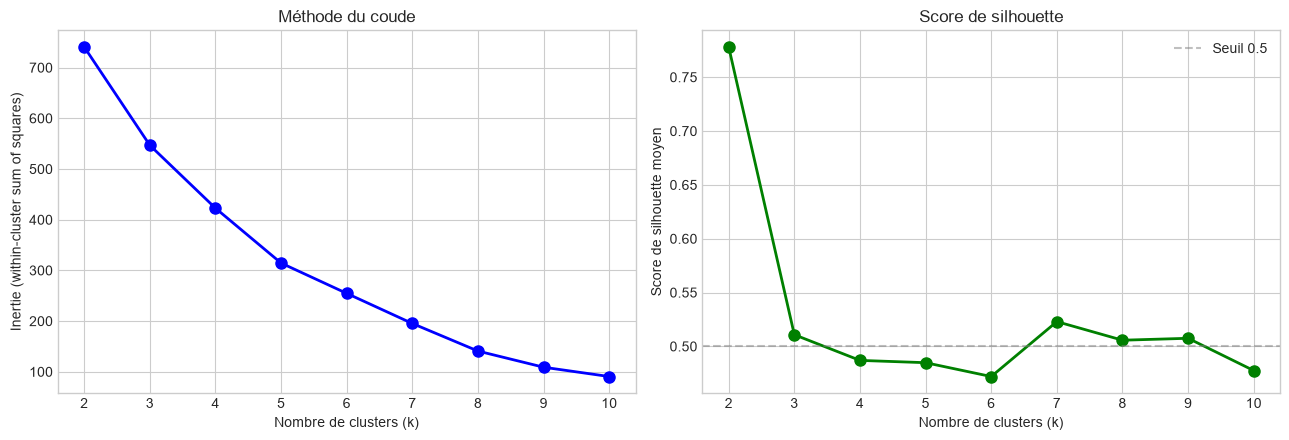

,k,inertie,silhouette
0,2,740.729556,0.778081
1,3,546.800280,0.510815
2,4,422.708300,0.486974
3,5,314.422051,0.484839
4,6,254.606511,0.471976
5,7,195.225977,0.522980
6,8,140.836277,0.505711
7,9,108.959995,0.507503
8,10,90.581801,0.477524


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(df_metrics["k"], df_metrics["inertie"], "bo-", linewidth=2, markersize=8)
axes[0].set_xlabel("Nombre de clusters (k)")
axes[0].set_ylabel("Inertie (within-cluster sum of squares)")
axes[0].set_title("Méthode du coude")
axes[0].set_xticks(list(K_RANGE))

axes[1].plot(df_metrics["k"], df_metrics["silhouette"], "go-", linewidth=2, markersize=8)
axes[1].set_xlabel("Nombre de clusters (k)")
axes[1].set_ylabel("Score de silhouette moyen")
axes[1].set_title("Score de silhouette")
axes[1].set_xticks(list(K_RANGE))
axes[1].axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Seuil 0.5")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "kmeans_evaluation_k2_10.png", dpi=150, bbox_inches="tight")
plt.show()

df_metrics.style.highlight_max(subset=["silhouette"], color="lightgreen")

### 3.2 Choix du *k* final

| Critère | *k* suggéré | Commentaire |
|---------|-------------|-------------|
| **Silhouette maximale** | k = 2 (0,78) | Sépare essentiellement l'Afrique du Sud et l'Égypte du reste du continent — clusters très déséquilibrés (52 vs 2 pays) |
| **Méthode du coude** | k = 4 | Rupture nette de pente après k = 4 ; compromis interprétabilité / granularité |
| **Silhouette (k > 2)** | k = 7 (0,52) | Meilleur score au-delà de k = 2, mais plusieurs clusters singletons |

**→ Choix retenu : k = 4**

Justification : bien que k = 2 maximise la silhouette, il ne produit qu'une segmentation binaire dominée par deux géants industriels (Afrique du Sud, Égypte). Le coude identifie k = 4 comme point de stabilisation de l'inertie. Ce choix distingue quatre profils énergétiques distincts tout en restant interprétable pour des décideurs.

In [5]:
K_FINAL = 4
km_final, labels_final = models[K_FINAL]
sil_final = silhouette_score(X, labels_final)

result = df_raw.copy()
result["Cluster"] = labels_final

print(f"Modèle final : k={K_FINAL}, silhouette={sil_final:.4f}")
print("\nEffectifs par cluster :")
print(result["Cluster"].value_counts().sort_index())

Modèle final : k=4, silhouette=0.4870

Effectifs par cluster :
Cluster
0    11
1     1
2     1
3    41
Name: count, dtype: int64


## 4. Analyse des clusters

### 4.1 Visualisation PCA (2 composantes principales)

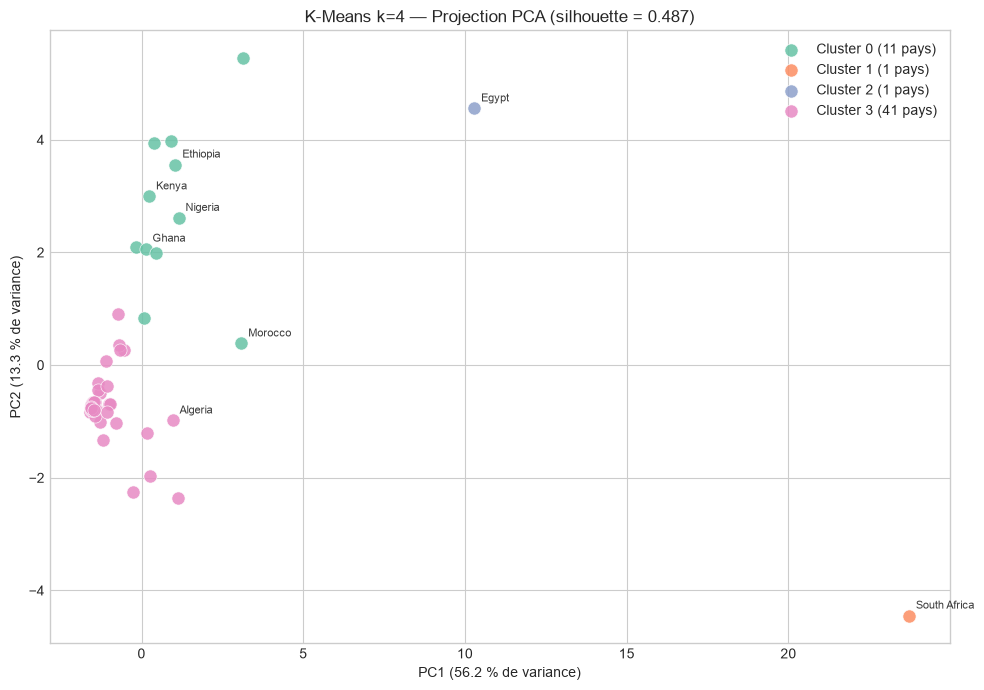

In [6]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette("Set2", K_FINAL)

for c in range(K_FINAL):
    mask = labels_final == c
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=[palette[c]], s=90, alpha=0.85,
        label=f"Cluster {c} ({mask.sum()} pays)",
        edgecolors="white", linewidth=0.5,
    )

major = ["South Africa", "Egypt", "Nigeria", "Kenya", "Morocco", "Ghana", "Ethiopia", "Algeria"]
for i, country in enumerate(countries):
    if country in major:
        ax.annotate(country, (X_pca[i, 0], X_pca[i, 1]), fontsize=8, alpha=0.9,
                    xytext=(5, 5), textcoords="offset points")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f} % de variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f} % de variance)")
ax.set_title(f"K-Means k={K_FINAL} — Projection PCA (silhouette = {sil_final:.3f})")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "kmeans_pca_k4.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.2 Distribution des scores de silhouette par cluster

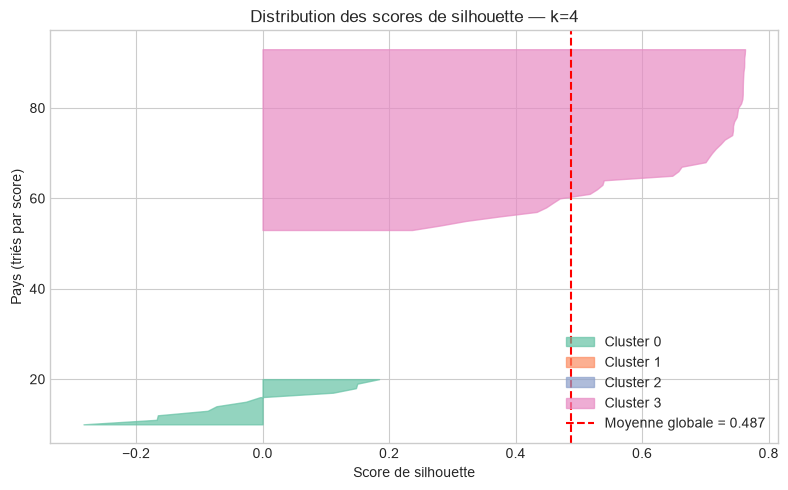

In [7]:
sample_sil = silhouette_samples(X, labels_final)

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
for c in range(K_FINAL):
    c_sil = sample_sil[labels_final == c]
    c_sil.sort()
    size = c_sil.shape[0]
    y_upper = y_lower + size
    color = sns.color_palette("Set2", K_FINAL)[c]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil, alpha=0.7, color=color, label=f"Cluster {c}")
    y_lower = y_upper + 10

ax.axvline(x=sil_final, color="red", linestyle="--", label=f"Moyenne globale = {sil_final:.3f}")
ax.set_xlabel("Score de silhouette")
ax.set_ylabel("Pays (triés par score)")
ax.set_title("Distribution des scores de silhouette — k=4")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "kmeans_silhouette_k4.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.3 Profils moyens par cluster (échelle originale)

Indicateurs clés pour l'interprétation énergétique :

In [8]:
key_indicators = [
    "Electricity final consumption per capita (KWh)",
    "Electricity generation, Total (GWh)",
    "Electricity generated from fossil fuels (GWh)",
    "Electricity generated from renewable sources (GWh)",
    "Electricity generated from hydropower (GWh)",
    "Electricity generated from nuclear power (GWh)",
    "Electricity generated from solar, wind, tide, wave and other sources (GWh)",
    "Electricity installed capacity, Total (MW)",
    "Electricity: Net imports ( GWh )",
]

profiles = result.groupby("Cluster")[key_indicators].mean().round(1)
profiles.index = [f"Cluster {i}" for i in profiles.index]
profiles.T

,Cluster 0,Cluster 1,Cluster 2,Cluster 3
Electricity final consumption per capita (KWh),340.7,3748.7,1530.6,483.9
"Electricity generation, Total (GWh)",13997.0,253872.4,163820.0,4068.0
Electricity generated from fossil fuels (GWh),6224.5,231890.0,147958.6,3490.3
Electricity generated from renewable sources (GWh),7772.5,9129.6,15861.4,577.7
Electricity generated from hydropower (GWh),7177.0,5222.7,13778.6,517.9
Electricity generated from nuclear power (GWh),0.0,12852.7,0.0,0.0
"Electricity generated from solar, wind, tide, wave and other sources (GWh)",291.3,3619.3,2082.8,18.5
"Electricity installed capacity, Total (MW)",3729.2,47749.7,36674.3,1060.7
Electricity: Net imports ( GWh ),92.7,-4004.7,-804.7,220.3


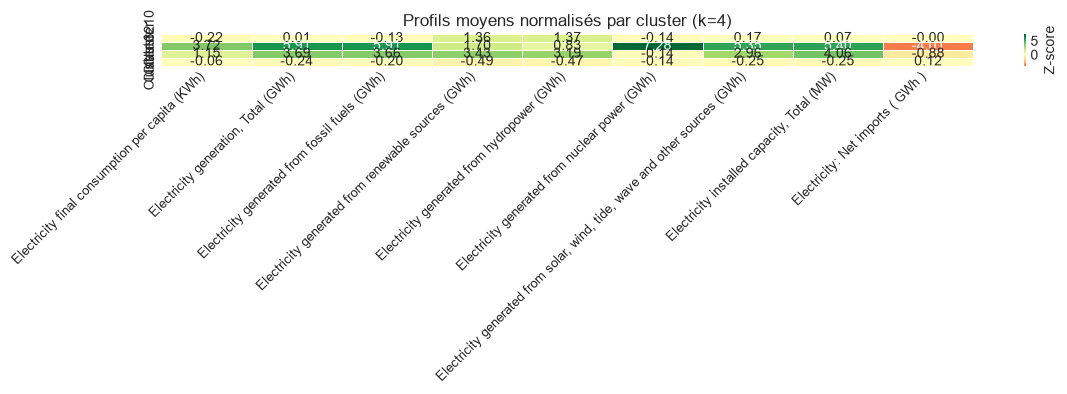

In [9]:
centroids_norm = pd.DataFrame(
    km_final.cluster_centers_,
    columns=feature_cols,
    index=[f"Cluster {i}" for i in range(K_FINAL)],
)

heatmap_cols = key_indicators
centroids_subset = centroids_norm[heatmap_cols]

plt.figure(figsize=(12, 4))
sns.heatmap(centroids_subset, cmap="RdYlGn", center=0, annot=True, fmt=".2f",
            linewidths=0.5, cbar_kws={"label": "Z-score"})
plt.title("Profils moyens normalisés par cluster (k=4)")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / "kmeans_heatmap_k4.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.4 Pays représentatifs par cluster

Pour chaque cluster, nous identifions les 5 pays les plus proches du centroïde (distance euclidienne dans l'espace normalisé).

In [10]:
representatives = {}

for c in range(K_FINAL):
    idx = np.where(labels_final == c)[0]
    dists = np.linalg.norm(X[idx] - km_final.cluster_centers_[c], axis=1)
    top5_idx = idx[np.argsort(dists)[:5]]
    reps = countries.iloc[top5_idx].tolist()
    representatives[c] = reps
    print(f"\nCluster {c} ({len(idx)} pays) — représentants : {', '.join(reps)}")

print("\n" + "=" * 60)
for c in range(K_FINAL):
    cl = sorted(result[result["Cluster"] == c]["Country"].tolist())
    print(f"\nCluster {c} — {len(cl)} pays :")
    print(", ".join(cl))


Cluster 0 (11 pays) — représentants : Angola, Ghana, Zambia, Congo Democratic Republic, Ethiopia

Cluster 1 (1 pays) — représentants : South Africa

Cluster 2 (1 pays) — représentants : Egypt

Cluster 3 (41 pays) — représentants : Congo Republic, Equatorial Guinea, Djibouti, Lesotho, Cape Verde


Cluster 0 — 11 pays :
Angola, Congo Democratic Republic, Ethiopia, Ghana, Kenya, Morocco, Mozambique, Nigeria, Sudan, Zambia, Zimbabwe

Cluster 1 — 1 pays :
South Africa

Cluster 2 — 1 pays :
Egypt

Cluster 3 — 41 pays :
Algeria, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Cape Verde, Central African Republic, Chad, Comoros, Congo Republic, Cote d'Ivoire, Djibouti, Equatorial Guinea, Eritrea, Eswatini, Gabon, Gambia, Guinea, Guinea Bissau, Lesotho, Liberia, Libya, Madagascar, Malawi, Mali, Mauritania, Mauritius, Namibia, Niger, Rwanda, Sao Tome and Principe, Senegal, Seychelles, Sierra Leone, Somalia, South Sudan, Tanzania, Togo, Tunisia, Uganda


### 4.5 Interprétation énergétique des clusters (k = 4)

---

#### **Cluster 0 — « Émergents à mix renouvelable » (11 pays)**
*Angola, Congo RDC, Éthiopie, Ghana, Kenya, Maroc, Mozambique, Nigeria, Soudan, Zambie, Zimbabwe*

- **Consommation modérée** (~341 kWh/hab) mais **production significative** (~14 000 GWh)
- **Mix énergétique diversifié** : forte part d'hydroélectricité et de renouvelables (~7 800 GWh) vs fossiles (~6 200 GWh)
- Pays en **transition énergétique** avec potentiel hydro (Éthiopie, Angola, Zambia) et éolien/solaire (Maroc, Kenya)
- **Enjeux** : fiabiliser le réseau, réduire la dépendance aux fossiles, étendre l'accès à l'électricité en milieu rural

---

#### **Cluster 1 — « Puissance industrielle nucléaire » (1 pays)**
*Afrique du Sud*

- **Consommation très élevée** (~3 749 kWh/hab) — niveau comparable aux économies émergentes
- **Production massive** (~254 000 GWh), dominée par le **charbon** (~232 000 GWh fossiles)
- Seul pays africain avec **nucléaire significatif** (~12 853 GWh) — 2 centrales (Koeberg)
- **Exportateur net** d'électricité vers les pays voisins
- **Enjeux** : transition énergétique post-charbon, vieillissement du parc nucléaire, load shedding

---

#### **Cluster 2 — « Géant fossile et renouvelable » (1 pays)**
*Égypte*

- **Consommation élevée** (~1 531 kWh/hab), **production importante** (~164 000 GWh)
- Mix dominé par le **gaz naturel** (~148 000 GWh fossiles) + **renouvelables croissantes** (~15 900 GWh, surtout hydro Assouan)
- **Capacité installée considérable**, importateur net historique devenant progressivement autosuffisant
- **Enjeux** : diversification (solaire dans le désert), satisfaction d'une demande urbaine croissante

---

#### **Cluster 3 — « Basse consommation / accès limité » (41 pays)**
*Majorité de l'Afrique subsaharienne*

- **Consommation faible** (~484 kWh/hab) — largement sous le seuil de 500 kWh/hab (accès limité)
- **Production modeste** (~4 000 GWh), mix **fossile dominant** (~3 500 GWh) avec peu de renouvelables (~578 GWh)
- **Importateurs nets** pour plusieurs pays (Bénin, Botswana, Burkina Faso…)
- **Enjeux prioritaires** : électrification rurale, mini-réseaux solaires, réduction des coupures, investissements en capacité de base

---

> **Synthèse pour décideurs :** Le continent africain présente une hétérogénéité extrême. Deux pays (Afrique du Sud, Égypte) concentrent à eux seuls la majorité de la production. Un groupe intermédiaire de 11 pays amorce une transition vers les renouvelables. Les 41 pays restants restent en situation de sous-équipement énergétique, avec des besoins d'investissement massifs en accès à l'électricité.

In [11]:
result.to_excel(OUT_DIR / "kmeans_affectation_k4.xlsx", index=False)
profiles.to_excel(OUT_DIR / "kmeans_profils_moyens_k4.xlsx")
df_metrics.to_excel(OUT_DIR / "kmeans_metriques_k2_10.xlsx", index=False)

print("Fichiers exportés dans :", OUT_DIR)
for f in sorted(OUT_DIR.glob("kmeans_*")):
    print(f"  - {f.name}")

Fichiers exportés dans : D:\BECKER\Eulogia\outputs
  - kmeans_affectation_k4.xlsx
  - kmeans_evaluation_k2_10.png
  - kmeans_heatmap_k2.png
  - kmeans_heatmap_k4.png
  - kmeans_metriques_k2_10.xlsx
  - kmeans_pca_k4.png
  - kmeans_profils_moyens_k2.xlsx
  - kmeans_profils_moyens_k4.xlsx
  - kmeans_resultats_k2.xlsx
  - kmeans_silhouette_k4.png


## 5. Synthèse des métriques K-Means (pour le Groupe 4)

| Métrique | Valeur |
|----------|--------|
| Algorithme | K-Means |
| *k* testés | 2 à 10 |
| *k* retenu | 4 |
| Silhouette (k=4) | ~0,49 |
| Silhouette max (k=2) | ~0,78 |
| Inertie (k=4) | ~423 |
| Nombre de pays | 54 |
| Variables | 25 (normalisées) |

*Ce notebook est prêt à être intégré dans le notebook final du Groupe 4 (section K-Means).*